BOND PARAMETERS
Yield to Maturity (YTM): 0.051303 = 5.1303%
Bond price at YTM: 99.000000 (should be 99)

GREEKS
Delta:             -762.47
Gamma:             7393
Speed:             -81184
Theta:             4.9530 per year
DV01:              0.07625
Modified Duration: 7.70 years
Macaulay Duration: 8.10 years

PROBABILITY OF 10% DECLINE IN 30 DAYS
30-day yield volatility: 0.03286 = 328.6 bp
Target price (10% decline): 89.10
Yield for 10% decline: 0.06589 = 6.589%
Required yield change: 0.01458 = 145.8 bp
Z-score: 0.4437
Probability of 10% decline: 0.3286 = 32.86%
MC validation (M=100,000): 0.3290 = 32.90%

CALCULATING VAR FOR ALL HORIZONS...
  Computing n = 1 days...
  Computing n = 10 days...
  Computing n = 20 days...
  Computing n = 30 days...
  Computing n = 40 days...
  Computing n = 50 days...
  Computing n = 60 days...
  Computing n = 70 days...
  Computing n = 80 days...
  Computing n = 90 days...

99% VAR RESULTS BY METHOD
   n |    Exact |    Delta |  D-Gamma |     MC+D |    

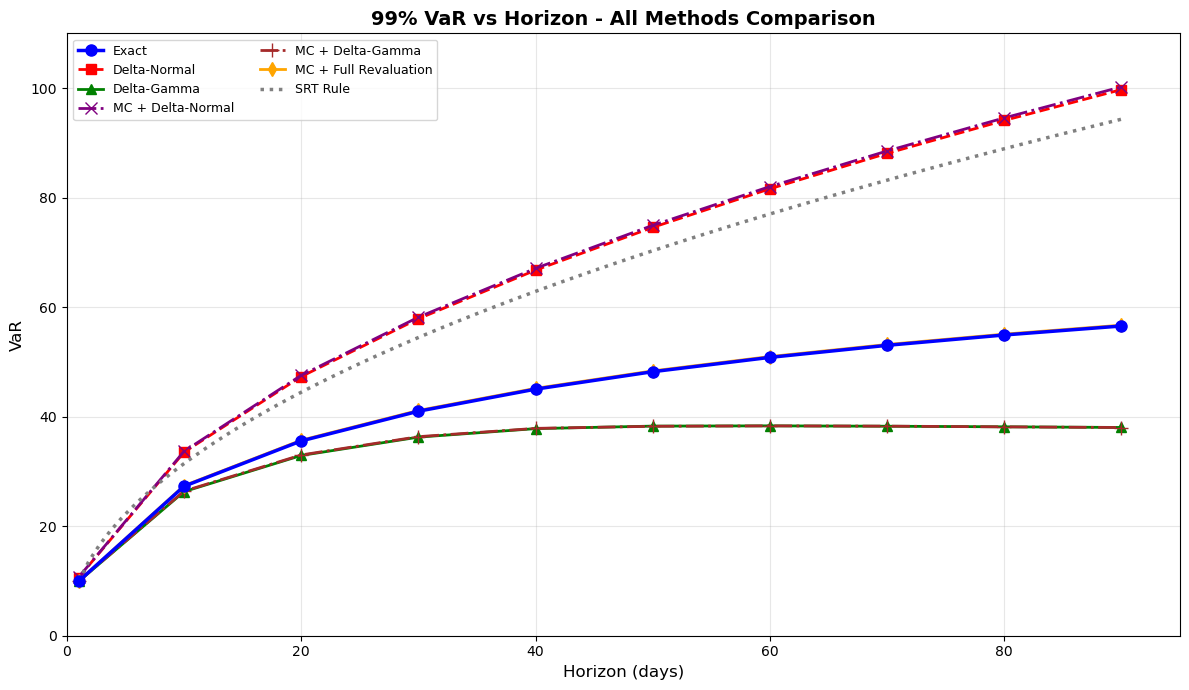

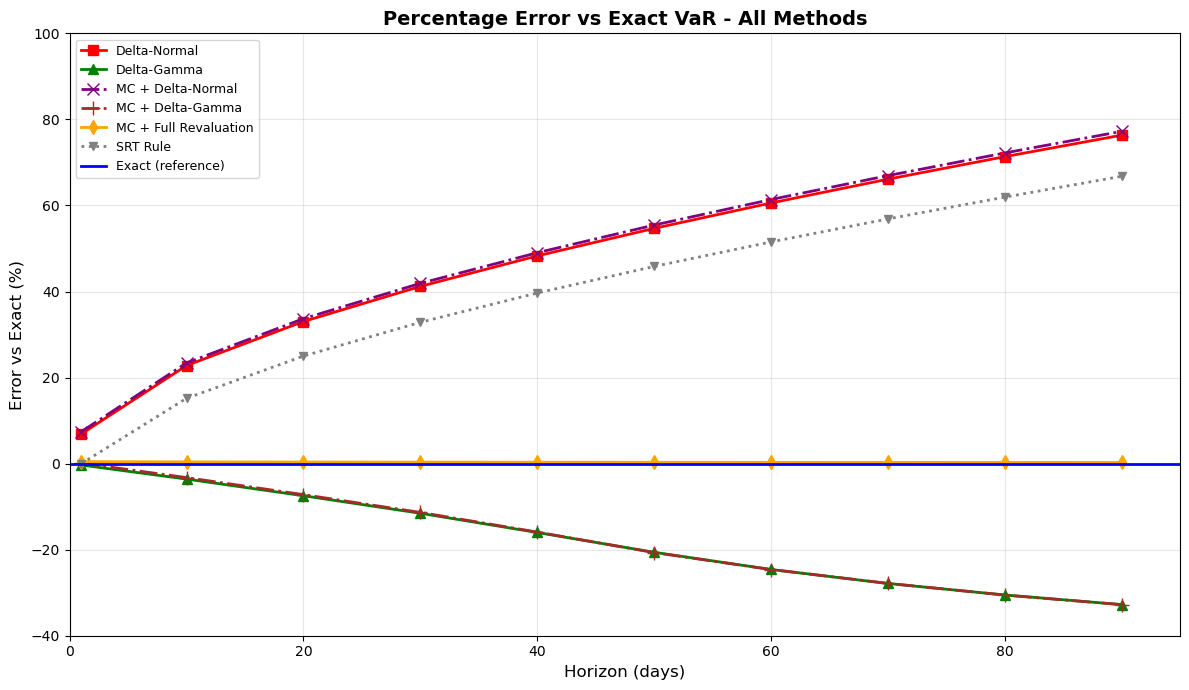

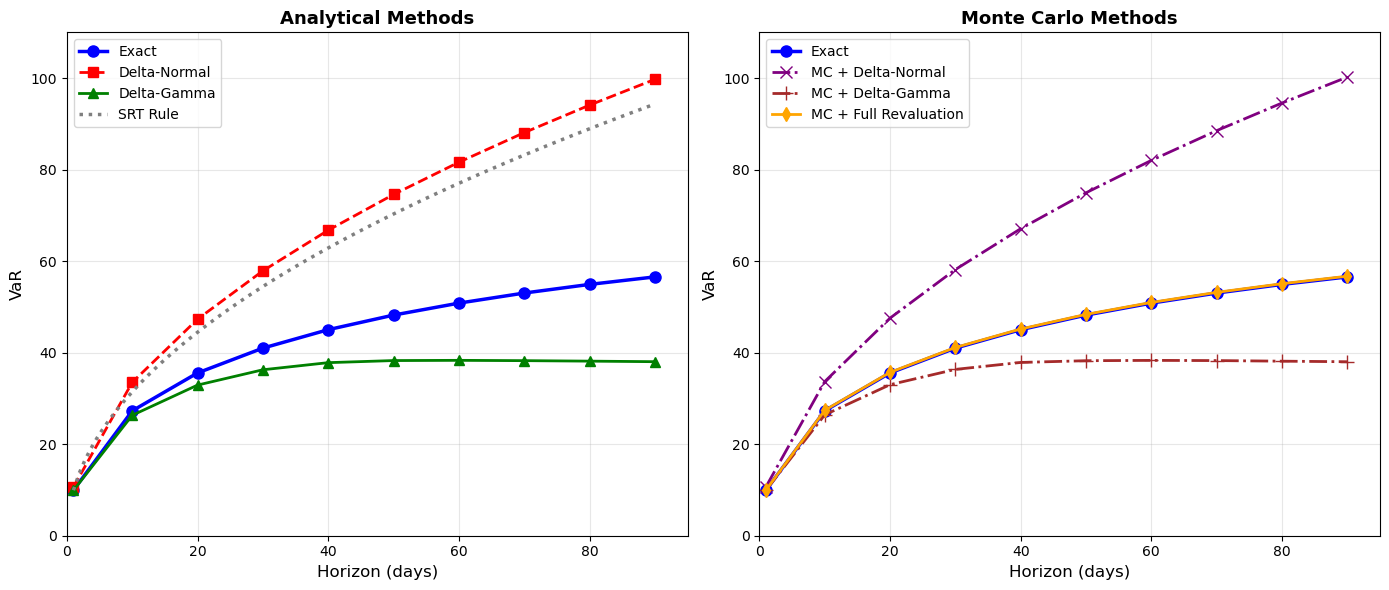

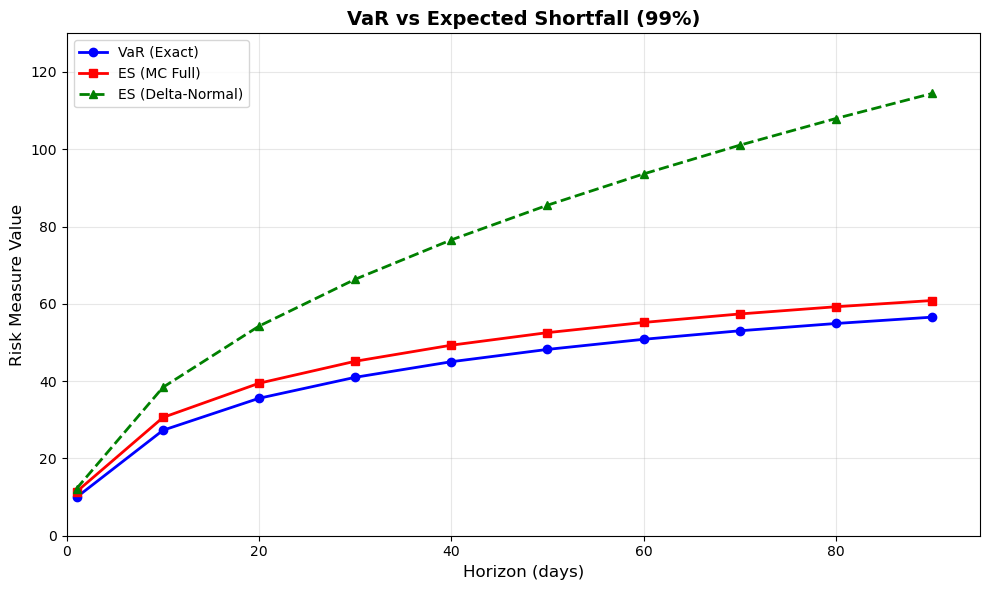

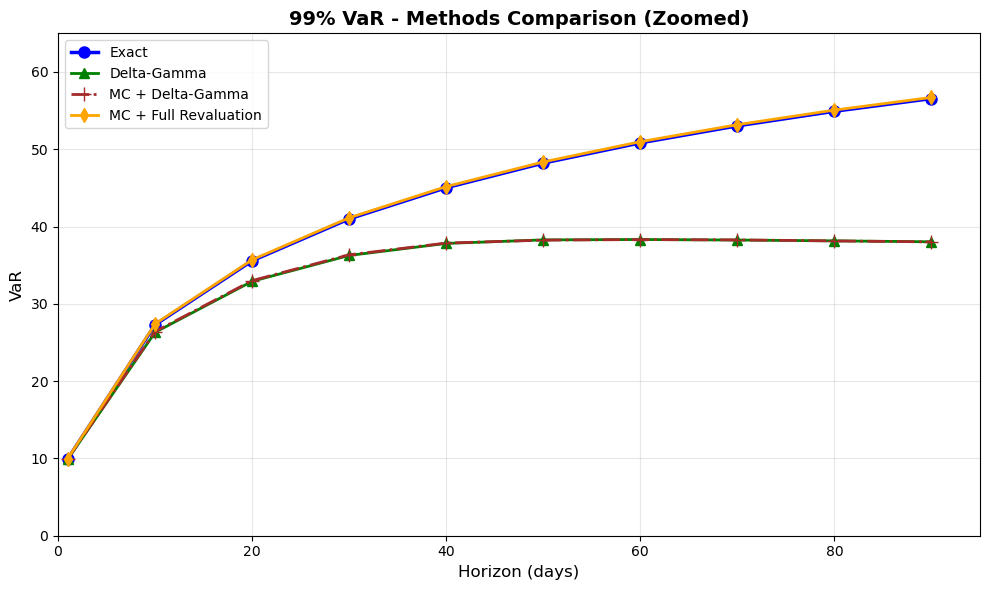

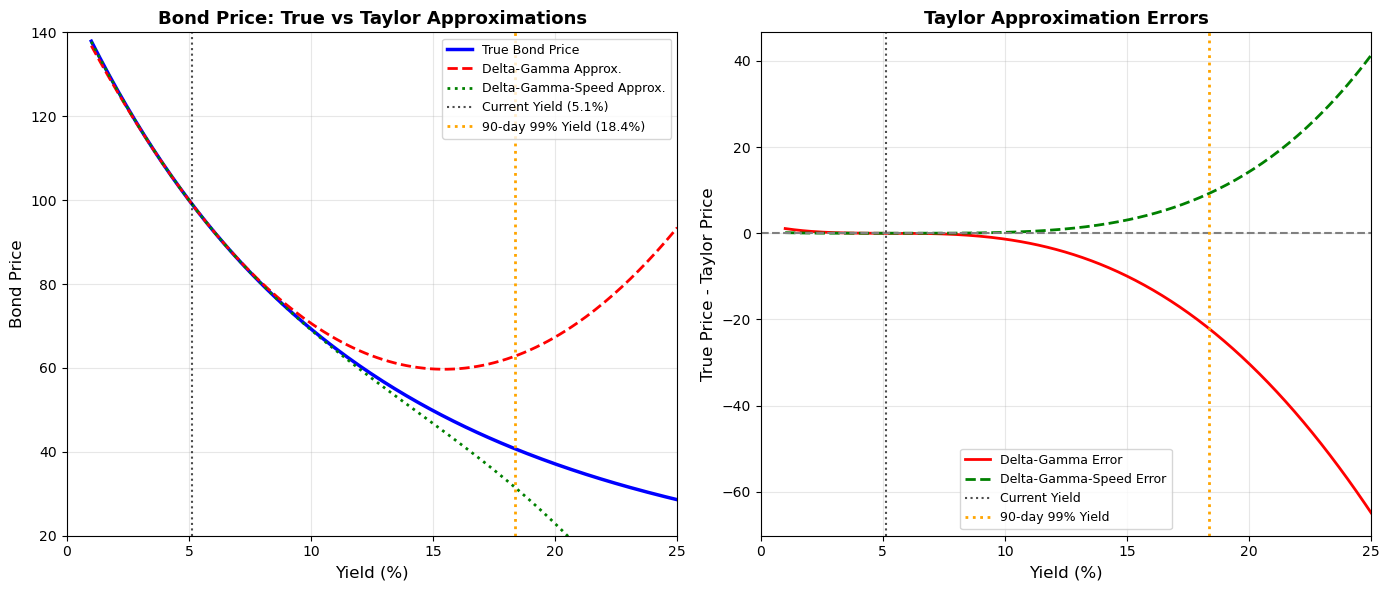

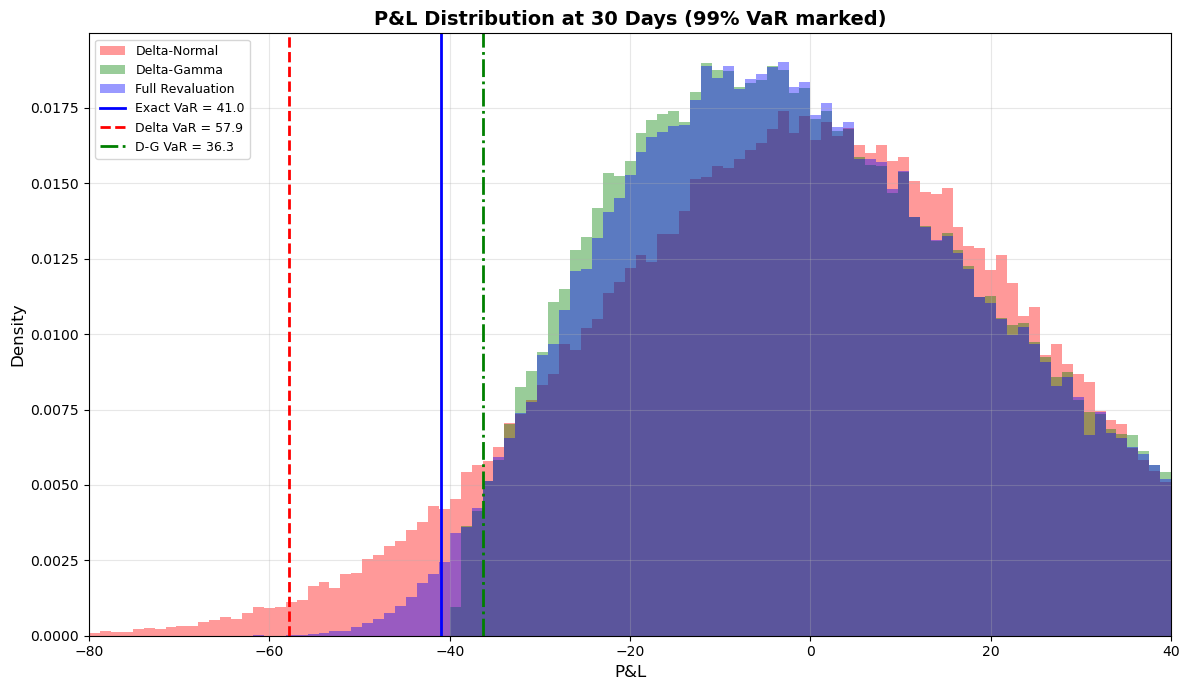


LATEX TABLE DATA FOR FIGURES

% Exact VaR coordinates:
\addplot[blue, thick, mark=*] coordinates {
    (1,9.94) (10,27.30) (20,35.57) (30,40.99) (40,45.03) (50,48.21) (60,50.83) (70,53.03) (80,54.92) (90,56.56)
};

% Delta-Normal VaR coordinates:
\addplot[red, dashed, thick, mark=square] coordinates {
    (1,10.63) (10,33.52) (20,47.32) (30,57.88) (40,66.76) (50,74.57) (60,81.61) (70,88.08) (80,94.09) (90,99.73)
};

% Delta-Gamma VaR coordinates:
\addplot[green!60!black, thick, mark=triangle] coordinates {
    (1,9.91) (10,26.32) (20,32.92) (30,36.26) (40,37.82) (50,38.28) (60,38.32) (70,38.26) (80,38.15) (90,38.03)
};

% MC+Delta VaR coordinates:
\addplot[purple, dashdotted, thick, mark=x] coordinates {
    (1,10.68) (10,33.68) (20,47.55) (30,58.17) (40,67.09) (50,74.94) (60,82.02) (70,88.52) (80,94.56) (90,100.22)
};

% MC+Delta-Gamma VaR coordinates:
\addplot[brown, dashdotted, thick, mark=+] coordinates {
    (1,9.95) (10,26.41) (20,33.01) (30,36.35) (40,37.86) (50,38.24) (60,38.3

In [7]:
import numpy as np
from scipy.optimize import brentq
from scipy.stats import norm
import matplotlib.pyplot as plt

# ══════════════════════════════════════════════════════════════════════════════
# BOND PARAMETERS
# ══════════════════════════════════════════════════════════════════════════════
F = 100          # Face value
C = 5            # Annual coupon
T = 10           # Maturity in years
P0 = 99          # Current price
sigma_y = 0.006  # Daily yield volatility (60 bp)
alpha = 0.01     # VaR confidence level (99%)
z_99 = norm.ppf(0.99)  # 2.3263
M = 10000        # Monte Carlo simulations

# Cash flows
cash_flows = [C] * 9 + [C + F]  # [5, 5, 5, 5, 5, 5, 5, 5, 5, 105]

# ══════════════════════════════════════════════════════════════════════════════
# BOND PRICING FUNCTION
# ══════════════════════════════════════════════════════════════════════════════
def bond_price(y, tau=0):
    """
    Calculate bond price given yield y and time elapsed tau (in years).
    """
    price = 0
    for k, cf in enumerate(cash_flows, start=1):
        price += cf / (1 + y) ** (k - tau)
    return price

# ══════════════════════════════════════════════════════════════════════════════
# FIND YIELD TO MATURITY
# ══════════════════════════════════════════════════════════════════════════════
y0 = brentq(lambda y: bond_price(y) - P0, 0.001, 0.30)
print("=" * 70)
print("BOND PARAMETERS")
print("=" * 70)
print(f"Yield to Maturity (YTM): {y0:.6f} = {y0*100:.4f}%")
print(f"Bond price at YTM: {bond_price(y0):.6f} (should be {P0})")

# ══════════════════════════════════════════════════════════════════════════════
# CALCULATE GREEKS (ANALYTICAL)
# ══════════════════════════════════════════════════════════════════════════════
# Delta = dP/dy
Delta = 0
for k, cf in enumerate(cash_flows, start=1):
    Delta += -k * cf / (1 + y0) ** (k + 1)

# Gamma = d²P/dy²
Gamma = 0
for k, cf in enumerate(cash_flows, start=1):
    Gamma += k * (k + 1) * cf / (1 + y0) ** (k + 2)

# Speed = d³P/dy³ (third derivative)
Speed = 0
for k, cf in enumerate(cash_flows, start=1):
    Speed += -k * (k + 1) * (k + 2) * cf / (1 + y0) ** (k + 3)

# Theta = dP/dτ at τ=0
Theta = np.log(1 + y0) * P0

# Derived measures
DV01 = abs(Delta) * 0.0001
mod_duration = -Delta / P0
mac_duration = mod_duration * (1 + y0)

print("\n" + "=" * 70)
print("GREEKS")
print("=" * 70)
print(f"Delta:             {Delta:.2f}")
print(f"Gamma:             {Gamma:.0f}")
print(f"Speed:             {Speed:.0f}")
print(f"Theta:             {Theta:.4f} per year")
print(f"DV01:              {DV01:.5f}")
print(f"Modified Duration: {mod_duration:.2f} years")
print(f"Macaulay Duration: {mac_duration:.2f} years")

# ══════════════════════════════════════════════════════════════════════════════
# PROBABILITY OF 10% DECLINE IN 30 DAYS
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("PROBABILITY OF 10% DECLINE IN 30 DAYS")
print("=" * 70)

n_prob = 30
sigma_30 = sigma_y * np.sqrt(n_prob)
target_price = 0.9 * P0  # 89.10
tau_30 = n_prob / 360

# Find yield that gives 10% decline
y_star = brentq(lambda y: bond_price(y, tau_30) - target_price, y0, 0.50)
delta_y_star = y_star - y0

prob_decline = 1 - norm.cdf(delta_y_star / sigma_30)

print(f"30-day yield volatility: {sigma_30:.5f} = {sigma_30*10000:.1f} bp")
print(f"Target price (10% decline): {target_price:.2f}")
print(f"Yield for 10% decline: {y_star:.5f} = {y_star*100:.3f}%")
print(f"Required yield change: {delta_y_star:.5f} = {delta_y_star*10000:.1f} bp")
print(f"Z-score: {delta_y_star / sigma_30:.4f}")
print(f"Probability of 10% decline: {prob_decline:.4f} = {prob_decline*100:.2f}%")

# Monte Carlo validation
np.random.seed(42)
mc_yield_changes = np.random.normal(0, sigma_30, 100000)
mc_prices = np.array([bond_price(y0 + dy, tau_30) for dy in mc_yield_changes])
mc_prob = np.mean(mc_prices <= target_price)
print(f"MC validation (M=100,000): {mc_prob:.4f} = {mc_prob*100:.2f}%")

# ══════════════════════════════════════════════════════════════════════════════
# VAR CALCULATION FUNCTIONS
# ══════════════════════════════════════════════════════════════════════════════

def var_exact(n):
    """Exact VaR via full revaluation at worst-case yield."""
    sigma_n = sigma_y * np.sqrt(n)
    y_worst = y0 + z_99 * sigma_n
    tau = n / 360
    P_worst = bond_price(y_worst, tau)
    return P0 - P_worst

def var_delta(n):
    """Delta-normal VaR."""
    tau = n / 360
    sigma_n = sigma_y * np.sqrt(n)
    return -Theta * tau + abs(Delta) * z_99 * sigma_n

def var_delta_gamma(n):
    """Delta-gamma VaR via quantile inversion."""
    tau = n / 360
    sigma_n = sigma_y * np.sqrt(n)
    mu_theta = Theta * tau
    a = Delta * sigma_n
    b = 0.5 * Gamma * sigma_n ** 2
    
    def cdf_delta_gamma(q):
        """CDF of delta-gamma P&L at value q."""
        c = q - mu_theta
        discriminant = a**2 + 4 * b * c
        if discriminant < 0:
            return 0.0
        sqrt_disc = np.sqrt(discriminant)
        Z_plus = (-a + sqrt_disc) / (2 * b)
        Z_minus = (-a - sqrt_disc) / (2 * b)
        return norm.cdf(Z_plus) - norm.cdf(Z_minus)
    
    # Find q such that CDF(q) = alpha
    q_min = -150
    q_max = 0
    q_alpha = brentq(lambda q: cdf_delta_gamma(q) - alpha, q_min, q_max)
    return -q_alpha

def var_mc_delta(n, seed=42):
    """Monte Carlo VaR with delta approximation."""
    np.random.seed(seed)
    tau = n / 360
    sigma_n = sigma_y * np.sqrt(n)
    Z = np.random.standard_normal(M)
    delta_y = sigma_n * Z
    pnl = Theta * tau + Delta * delta_y
    pnl_sorted = np.sort(pnl)
    k = int(np.ceil(M * alpha))
    return -pnl_sorted[k - 1]

def var_mc_delta_gamma(n, seed=42):
    """Monte Carlo VaR with delta-gamma approximation."""
    np.random.seed(seed)
    tau = n / 360
    sigma_n = sigma_y * np.sqrt(n)
    Z = np.random.standard_normal(M)
    delta_y = sigma_n * Z
    pnl = Theta * tau + Delta * delta_y + 0.5 * Gamma * delta_y ** 2
    pnl_sorted = np.sort(pnl)
    k = int(np.ceil(M * alpha))
    return -pnl_sorted[k - 1]

def var_mc_full(n, seed=42):
    """Monte Carlo VaR with full revaluation."""
    np.random.seed(seed)
    tau = n / 360
    sigma_n = sigma_y * np.sqrt(n)
    Z = np.random.standard_normal(M)
    delta_y = sigma_n * Z
    pnl = np.array([bond_price(y0 + dy, tau) - P0 for dy in delta_y])
    pnl_sorted = np.sort(pnl)
    k = int(np.ceil(M * alpha))
    return -pnl_sorted[k - 1]

# ══════════════════════════════════════════════════════════════════════════════
# CALCULATE VAR FOR ALL HORIZONS
# ══════════════════════════════════════════════════════════════════════════════
horizons = [1, 10, 20, 30, 40, 50, 60, 70, 80, 90]

results = {
    'n': horizons,
    'exact': [],
    'delta': [],
    'delta_gamma': [],
    'mc_delta': [],
    'mc_delta_gamma': [],
    'mc_full': [],
    'srt': []
}

print("\n" + "=" * 70)
print("CALCULATING VAR FOR ALL HORIZONS...")
print("=" * 70)

for n in horizons:
    print(f"  Computing n = {n} days...")
    results['exact'].append(var_exact(n))
    results['delta'].append(var_delta(n))
    results['delta_gamma'].append(var_delta_gamma(n))
    results['mc_delta'].append(var_mc_delta(n))
    results['mc_delta_gamma'].append(var_mc_delta_gamma(n))
    results['mc_full'].append(var_mc_full(n))
    results['srt'].append(var_exact(1) * np.sqrt(n))

# ══════════════════════════════════════════════════════════════════════════════
# PRINT VAR RESULTS TABLE
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 120)
print("99% VAR RESULTS BY METHOD")
print("=" * 120)
print(f"{'n':>4} | {'Exact':>8} | {'Delta':>8} | {'D-Gamma':>8} | {'MC+D':>8} | {'MC+DG':>8} | {'MC+Full':>8} | {'SRT':>8}")
print("-" * 120)
for i, n in enumerate(horizons):
    print(f"{n:4d} | {results['exact'][i]:8.2f} | {results['delta'][i]:8.2f} | "
          f"{results['delta_gamma'][i]:8.2f} | {results['mc_delta'][i]:8.2f} | "
          f"{results['mc_delta_gamma'][i]:8.2f} | {results['mc_full'][i]:8.2f} | "
          f"{results['srt'][i]:8.2f}")

# ══════════════════════════════════════════════════════════════════════════════
# PRINT ERROR TABLE
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 100)
print("PERCENTAGE ERRORS VS EXACT VAR")
print("=" * 100)
print(f"{'n':>4} | {'Delta':>10} | {'D-Gamma':>10} | {'MC+D':>10} | {'MC+DG':>10} | {'MC+Full':>10} | {'SRT':>10}")
print("-" * 100)
for i, n in enumerate(horizons):
    exact = results['exact'][i]
    err_delta = (results['delta'][i] - exact) / exact * 100
    err_dg = (results['delta_gamma'][i] - exact) / exact * 100
    err_mc_d = (results['mc_delta'][i] - exact) / exact * 100
    err_mc_dg = (results['mc_delta_gamma'][i] - exact) / exact * 100
    err_mc_f = (results['mc_full'][i] - exact) / exact * 100
    err_srt = (results['srt'][i] - exact) / exact * 100
    print(f"{n:4d} | {err_delta:+9.1f}% | {err_dg:+9.1f}% | "
          f"{err_mc_d:+9.1f}% | {err_mc_dg:+9.1f}% | {err_mc_f:+9.1f}% | {err_srt:+9.1f}%")

# ══════════════════════════════════════════════════════════════════════════════
# EXPECTED SHORTFALL CALCULATION
# ══════════════════════════════════════════════════════════════════════════════
def es_mc_full(n, seed=42):
    """Expected Shortfall via Monte Carlo with full revaluation."""
    np.random.seed(seed)
    tau = n / 360
    sigma_n = sigma_y * np.sqrt(n)
    Z = np.random.standard_normal(M)
    delta_y = sigma_n * Z
    pnl = np.array([bond_price(y0 + dy, tau) - P0 for dy in delta_y])
    pnl_sorted = np.sort(pnl)
    k = int(np.ceil(M * alpha))
    return -np.mean(pnl_sorted[:k])

def es_delta_normal(n):
    """Delta-normal Expected Shortfall."""
    tau = n / 360
    sigma_pnl = abs(Delta) * sigma_y * np.sqrt(n)
    mu_pnl = Theta * tau
    return -mu_pnl + sigma_pnl * norm.pdf(z_99) / alpha

print("\n" + "=" * 80)
print("EXPECTED SHORTFALL (99%)")
print("=" * 80)
print(f"{'n':>4} | {'VaR Exact':>10} | {'ES MC Full':>10} | {'ES Delta':>10} | {'ES/VaR':>8}")
print("-" * 80)

es_results = {'n': horizons, 'es_mc': [], 'es_delta': []}
for i, n in enumerate(horizons):
    es_mc = es_mc_full(n)
    es_d = es_delta_normal(n)
    es_results['es_mc'].append(es_mc)
    es_results['es_delta'].append(es_d)
    ratio = es_mc / results['exact'][i]
    print(f"{n:4d} | {results['exact'][i]:10.2f} | {es_mc:10.2f} | {es_d:10.2f} | {ratio:8.3f}")

# ══════════════════════════════════════════════════════════════════════════════
# SCENARIO DECOMPOSITION AT 90 DAYS
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("SCENARIO DECOMPOSITION AT 90 DAYS (99% YIELD SHOCK)")
print("=" * 70)

n_90 = 90
tau_90 = n_90 / 360
sigma_90 = sigma_y * np.sqrt(n_90)
delta_y_99 = z_99 * sigma_90

theta_component = Theta * tau_90
delta_component = Delta * delta_y_99
gamma_component = 0.5 * Gamma * delta_y_99 ** 2
speed_component = (1/6) * Speed * delta_y_99 ** 3

print(f"99% yield shock: {delta_y_99:.5f} = {delta_y_99*100:.2f}%")
print(f"New yield: {y0*100:.2f}% → {(y0+delta_y_99)*100:.2f}%")
print(f"Yield change relative to y0: {delta_y_99/y0*100:.0f}%")
print(f"")
print(f"Theta contribution:  {theta_component:+.2f}")
print(f"Delta contribution:  {delta_component:+.2f}")
print(f"Gamma contribution:  {gamma_component:+.2f}")
print(f"Speed contribution:  {speed_component:+.2f}")
print(f"")
print(f"Delta-only P&L:          {theta_component + delta_component:+.2f}")
print(f"Delta-Gamma P&L:         {theta_component + delta_component + gamma_component:+.2f}")
print(f"Delta-Gamma-Speed P&L:   {theta_component + delta_component + gamma_component + speed_component:+.2f}")
print(f"True P&L:                {bond_price(y0 + delta_y_99, tau_90) - P0:+.2f}")
print(f"")
print(f"Delta-Gamma VaR (quantile): {results['delta_gamma'][horizons.index(90)]:.2f}")
print(f"Exact VaR:                  {results['exact'][horizons.index(90)]:.2f}")

# ══════════════════════════════════════════════════════════════════════════════
# DIAGNOSTIC: WHY DELTA-GAMMA FAILS
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("DIAGNOSTIC: TAYLOR EXPANSION BREAKDOWN")
print("=" * 70)

print(f"\n{'n':>4} | {'σ_n':>8} | {'99% Δy':>10} | {'Δy/y0':>8} | {'Taylor P&L':>12} | {'True P&L':>10} | {'Error':>8}")
print("-" * 85)

for n in horizons:
    sigma_n = sigma_y * np.sqrt(n)
    delta_y = z_99 * sigma_n
    tau = n / 360
    
    # Taylor expansion (Delta-Gamma)
    taylor_pnl = Theta * tau + Delta * delta_y + 0.5 * Gamma * delta_y**2
    
    # True P&L
    true_pnl = bond_price(y0 + delta_y, tau) - P0
    
    error = taylor_pnl - true_pnl
    
    print(f"{n:4d} | {sigma_n:8.4f} | {delta_y*100:9.2f}% | {delta_y/y0:7.0%} | "
          f"{taylor_pnl:12.2f} | {true_pnl:10.2f} | {error:+8.2f}")

print("\n⚠️  Note: Δy/y0 > 100% means Taylor expansion is unreliable!")

# ══════════════════════════════════════════════════════════════════════════════
# MC CONVERGENCE ANALYSIS
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("MC CONVERGENCE ANALYSIS AT n=30 DAYS")
print("=" * 70)

n_conv = 30
M_values = [1000, 5000, 10000, 50000, 100000]

print(f"{'M':>8} | {'MC+Delta':>12} | {'MC+D-Gamma':>12} | {'MC+Full':>12}")
print("-" * 60)

for M_test in M_values:
    np.random.seed(42)
    tau = n_conv / 360
    sigma_n = sigma_y * np.sqrt(n_conv)
    Z = np.random.standard_normal(M_test)
    delta_y = sigma_n * Z
    
    # MC + Delta
    pnl_d = Theta * tau + Delta * delta_y
    k = int(np.ceil(M_test * alpha))
    var_mc_d = -np.sort(pnl_d)[k - 1]
    
    # MC + Delta-Gamma
    pnl_dg = Theta * tau + Delta * delta_y + 0.5 * Gamma * delta_y ** 2
    var_mc_dg = -np.sort(pnl_dg)[k - 1]
    
    # MC + Full
    pnl_full = np.array([bond_price(y0 + dy, tau) - P0 for dy in delta_y])
    var_mc_full_test = -np.sort(pnl_full)[k - 1]
    
    print(f"{M_test:8d} | {var_mc_d:12.2f} | {var_mc_dg:12.2f} | {var_mc_full_test:12.2f}")

print(f"\nExact VaR at n=30: {var_exact(30):.2f}")
print(f"Delta-Gamma VaR at n=30: {var_delta_gamma(30):.2f}")

# ══════════════════════════════════════════════════════════════════════════════
# RECOMMENDATIONS BY HORIZON
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("RECOMMENDATIONS BY HORIZON")
print("=" * 70)
print(f"\n{'Horizon':>10} | {'99% Δy':>10} | {'Δy/y0':>8} | {'Recommended Method':>30}")
print("-" * 70)
for n in horizons:
    delta_y = z_99 * sigma_y * np.sqrt(n)
    ratio = delta_y / y0
    if ratio < 0.3:
        method = "✓ Delta-Gamma OK"
    elif ratio < 0.5:
        method = "⚠ Delta-Gamma with caution"
    elif ratio < 1.0:
        method = "⚠ Prefer MC+Full"
    else:
        method = "✗ Use MC+Full Revaluation"
    print(f"{n:>10} | {delta_y*100:>9.2f}% | {ratio:>7.0%} | {method:>30}")

# ══════════════════════════════════════════════════════════════════════════════
# GENERATE FIGURES
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("GENERATING FIGURES...")
print("=" * 70)

# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 1: VAR VS HORIZON (ALL 7 METHODS)
# ══════════════════════════════════════════════════════════════════════════════
fig1, ax1 = plt.subplots(figsize=(12, 7))

# Exact (benchmark)
ax1.plot(horizons, results['exact'], 'b-o', linewidth=2.5, markersize=8, label='Exact', zorder=10)

# Analytical methods
ax1.plot(horizons, results['delta'], 'r--s', linewidth=2, markersize=7, label='Delta-Normal')
ax1.plot(horizons, results['delta_gamma'], 'g-^', linewidth=2, markersize=7, label='Delta-Gamma')

# Monte Carlo methods
ax1.plot(horizons, results['mc_delta'], 'purple', linestyle='-.', marker='x', 
         linewidth=2, markersize=8, label='MC + Delta-Normal')
ax1.plot(horizons, results['mc_delta_gamma'], 'brown', linestyle='-.', marker='+', 
         linewidth=2, markersize=10, label='MC + Delta-Gamma')
ax1.plot(horizons, results['mc_full'], 'orange', marker='d', linewidth=2, 
         markersize=7, label='MC + Full Revaluation')

# SRT Rule
n_continuous = np.linspace(1, 90, 100)
srt_continuous = results['exact'][0] * np.sqrt(n_continuous)
ax1.plot(n_continuous, srt_continuous, 'gray', linestyle=':', linewidth=2.5, label='SRT Rule')

ax1.set_xlabel('Horizon (days)', fontsize=12)
ax1.set_ylabel('VaR', fontsize=12)
ax1.set_title('99% VaR vs Horizon - All Methods Comparison', fontsize=14, fontweight='bold')
ax1.legend(loc='upper left', fontsize=9, ncol=2)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, 95)
ax1.set_ylim(0, 110)

plt.tight_layout()
plt.savefig('figure1_var_vs_horizon_all_methods.png', dpi=300, bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 2: PERCENTAGE ERROR VS HORIZON (ALL METHODS)
# ══════════════════════════════════════════════════════════════════════════════
fig2, ax2 = plt.subplots(figsize=(12, 7))

errors_delta = [(results['delta'][i] - results['exact'][i]) / results['exact'][i] * 100 
                for i in range(len(horizons))]
errors_dg = [(results['delta_gamma'][i] - results['exact'][i]) / results['exact'][i] * 100 
             for i in range(len(horizons))]
errors_mc_delta = [(results['mc_delta'][i] - results['exact'][i]) / results['exact'][i] * 100 
                   for i in range(len(horizons))]
errors_mc_dg = [(results['mc_delta_gamma'][i] - results['exact'][i]) / results['exact'][i] * 100 
                for i in range(len(horizons))]
errors_mc_full = [(results['mc_full'][i] - results['exact'][i]) / results['exact'][i] * 100 
                  for i in range(len(horizons))]
errors_srt = [(results['srt'][i] - results['exact'][i]) / results['exact'][i] * 100 
              for i in range(len(horizons))]

ax2.plot(horizons, errors_delta, 'r-s', linewidth=2, markersize=7, label='Delta-Normal')
ax2.plot(horizons, errors_dg, 'g-^', linewidth=2, markersize=7, label='Delta-Gamma')
ax2.plot(horizons, errors_mc_delta, 'purple', linestyle='-.', marker='x', 
         linewidth=2, markersize=8, label='MC + Delta-Normal')
ax2.plot(horizons, errors_mc_dg, 'brown', linestyle='-.', marker='+', 
         linewidth=2, markersize=10, label='MC + Delta-Gamma')
ax2.plot(horizons, errors_mc_full, 'orange', marker='d', linewidth=2, 
         markersize=7, label='MC + Full Revaluation')
ax2.plot(horizons, errors_srt, 'gray', linestyle=':', marker='v', linewidth=2, 
         markersize=6, label='SRT Rule')
ax2.axhline(y=0, color='blue', linestyle='-', linewidth=2, label='Exact (reference)')

ax2.set_xlabel('Horizon (days)', fontsize=12)
ax2.set_ylabel('Error vs Exact (%)', fontsize=12)
ax2.set_title('Percentage Error vs Exact VaR - All Methods', fontsize=14, fontweight='bold')
ax2.legend(loc='upper left', fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 95)
ax2.set_ylim(-40, 100)

plt.tight_layout()
plt.savefig('figure2_error_vs_horizon_all_methods.png', dpi=300, bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 3: ANALYTICAL VS MC METHODS (SIDE BY SIDE)
# ══════════════════════════════════════════════════════════════════════════════
fig3, (ax3a, ax3b) = plt.subplots(1, 2, figsize=(14, 6))

# Left panel: Analytical methods
ax3a.plot(horizons, results['exact'], 'b-o', linewidth=2.5, markersize=8, label='Exact')
ax3a.plot(horizons, results['delta'], 'r--s', linewidth=2, markersize=7, label='Delta-Normal')
ax3a.plot(horizons, results['delta_gamma'], 'g-^', linewidth=2, markersize=7, label='Delta-Gamma')
ax3a.plot(n_continuous, srt_continuous, 'gray', linestyle=':', linewidth=2.5, label='SRT Rule')

ax3a.set_xlabel('Horizon (days)', fontsize=12)
ax3a.set_ylabel('VaR', fontsize=12)
ax3a.set_title('Analytical Methods', fontsize=13, fontweight='bold')
ax3a.legend(loc='upper left', fontsize=10)
ax3a.grid(True, alpha=0.3)
ax3a.set_xlim(0, 95)
ax3a.set_ylim(0, 110)

# Right panel: Monte Carlo methods
ax3b.plot(horizons, results['exact'], 'b-o', linewidth=2.5, markersize=8, label='Exact')
ax3b.plot(horizons, results['mc_delta'], 'purple', linestyle='-.', marker='x', 
          linewidth=2, markersize=8, label='MC + Delta-Normal')
ax3b.plot(horizons, results['mc_delta_gamma'], 'brown', linestyle='-.', marker='+', 
          linewidth=2, markersize=10, label='MC + Delta-Gamma')
ax3b.plot(horizons, results['mc_full'], 'orange', marker='d', linewidth=2, 
          markersize=7, label='MC + Full Revaluation')

ax3b.set_xlabel('Horizon (days)', fontsize=12)
ax3b.set_ylabel('VaR', fontsize=12)
ax3b.set_title('Monte Carlo Methods', fontsize=13, fontweight='bold')
ax3b.legend(loc='upper left', fontsize=10)
ax3b.grid(True, alpha=0.3)
ax3b.set_xlim(0, 95)
ax3b.set_ylim(0, 110)

plt.tight_layout()
plt.savefig('figure3_analytical_vs_mc.png', dpi=300, bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 4: VAR AND ES COMPARISON
# ══════════════════════════════════════════════════════════════════════════════
fig4, ax4 = plt.subplots(figsize=(10, 6))

ax4.plot(horizons, results['exact'], 'b-o', linewidth=2, markersize=6, label='VaR (Exact)')
ax4.plot(horizons, es_results['es_mc'], 'r-s', linewidth=2, markersize=6, label='ES (MC Full)')
ax4.plot(horizons, es_results['es_delta'], 'g--^', linewidth=2, markersize=6, label='ES (Delta-Normal)')

ax4.set_xlabel('Horizon (days)', fontsize=12)
ax4.set_ylabel('Risk Measure Value', fontsize=12)
ax4.set_title('VaR vs Expected Shortfall (99%)', fontsize=14, fontweight='bold')
ax4.legend(loc='upper left', fontsize=10)
ax4.grid(True, alpha=0.3)
ax4.set_xlim(0, 95)
ax4.set_ylim(0, 130)

plt.tight_layout()
plt.savefig('figure4_var_vs_es.png', dpi=300, bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 5: ZOOMED VIEW - ACCURATE METHODS ONLY
# ══════════════════════════════════════════════════════════════════════════════
fig5, ax5 = plt.subplots(figsize=(10, 6))

ax5.plot(horizons, results['exact'], 'b-o', linewidth=2.5, markersize=8, label='Exact')
ax5.plot(horizons, results['delta_gamma'], 'g-^', linewidth=2, markersize=7, label='Delta-Gamma')
ax5.plot(horizons, results['mc_delta_gamma'], 'brown', linestyle='-.', marker='+', 
         linewidth=2, markersize=10, label='MC + Delta-Gamma')
ax5.plot(horizons, results['mc_full'], 'orange', marker='d', linewidth=2, 
         markersize=7, label='MC + Full Revaluation')

ax5.set_xlabel('Horizon (days)', fontsize=12)
ax5.set_ylabel('VaR', fontsize=12)
ax5.set_title('99% VaR - Methods Comparison (Zoomed)', fontsize=14, fontweight='bold')
ax5.legend(loc='upper left', fontsize=10)
ax5.grid(True, alpha=0.3)
ax5.set_xlim(0, 95)
ax5.set_ylim(0, 65)

plt.tight_layout()
plt.savefig('figure5_accurate_methods.png', dpi=300, bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 6: BOND PRICE - TRUE VS TAYLOR APPROXIMATION
# ══════════════════════════════════════════════════════════════════════════════
fig6, (ax6a, ax6b) = plt.subplots(1, 2, figsize=(14, 6))

# Left: Price curves
y_range = np.linspace(0.01, 0.25, 200)
true_prices = [bond_price(y) for y in y_range]
taylor_prices = [P0 + Delta * (y - y0) + 0.5 * Gamma * (y - y0)**2 for y in y_range]
taylor_3rd = [P0 + Delta * (y - y0) + 0.5 * Gamma * (y - y0)**2 + (1/6) * Speed * (y - y0)**3 
              for y in y_range]

ax6a.plot(y_range * 100, true_prices, 'b-', linewidth=2.5, label='True Bond Price')
ax6a.plot(y_range * 100, taylor_prices, 'r--', linewidth=2, label='Delta-Gamma Approx.')
ax6a.plot(y_range * 100, taylor_3rd, 'g:', linewidth=2, label='Delta-Gamma-Speed Approx.')
ax6a.axvline(x=y0 * 100, color='black', linestyle=':', alpha=0.7, label=f'Current Yield ({y0*100:.1f}%)')
ax6a.axvline(x=(y0 + z_99 * sigma_y * np.sqrt(90)) * 100, color='orange', linestyle=':', 
            linewidth=2, label=f'90-day 99% Yield ({(y0 + z_99 * sigma_y * np.sqrt(90))*100:.1f}%)')

ax6a.set_xlabel('Yield (%)', fontsize=12)
ax6a.set_ylabel('Bond Price', fontsize=12)
ax6a.set_title('Bond Price: True vs Taylor Approximations', fontsize=13, fontweight='bold')
ax6a.legend(loc='upper right', fontsize=9)
ax6a.grid(True, alpha=0.3)
ax6a.set_xlim(0, 25)
ax6a.set_ylim(20, 140)

# Right: Approximation error
errors_taylor = [true_prices[i] - taylor_prices[i] for i in range(len(y_range))]
errors_taylor_3rd = [true_prices[i] - taylor_3rd[i] for i in range(len(y_range))]

ax6b.plot(y_range * 100, errors_taylor, 'r-', linewidth=2, label='Delta-Gamma Error')
ax6b.plot(y_range * 100, errors_taylor_3rd, 'g--', linewidth=2, label='Delta-Gamma-Speed Error')
ax6b.axhline(y=0, color='gray', linestyle='--')
ax6b.axvline(x=y0 * 100, color='black', linestyle=':', alpha=0.7, label=f'Current Yield')
ax6b.axvline(x=(y0 + z_99 * sigma_y * np.sqrt(90)) * 100, color='orange', linestyle=':', 
            linewidth=2, label=f'90-day 99% Yield')

ax6b.set_xlabel('Yield (%)', fontsize=12)
ax6b.set_ylabel('True Price - Taylor Price', fontsize=12)
ax6b.set_title('Taylor Approximation Errors', fontsize=13, fontweight='bold')
ax6b.legend(fontsize=9)
ax6b.grid(True, alpha=0.3)
ax6b.set_xlim(0, 25)

plt.tight_layout()
plt.savefig('figure6_taylor_approximation.png', dpi=300, bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 7: P&L DISTRIBUTION AT 30 DAYS
# ══════════════════════════════════════════════════════════════════════════════
fig7, ax7 = plt.subplots(figsize=(12, 7))

n_plot = 30
tau_plot = n_plot / 360
sigma_n_plot = sigma_y * np.sqrt(n_plot)

np.random.seed(42)
Z_plot = np.random.standard_normal(100000)
delta_y_plot = sigma_n_plot * Z_plot

# Calculate P&L for each method
pnl_delta = Theta * tau_plot + Delta * delta_y_plot
pnl_dg = Theta * tau_plot + Delta * delta_y_plot + 0.5 * Gamma * delta_y_plot**2
pnl_full = np.array([bond_price(y0 + dy, tau_plot) - P0 for dy in delta_y_plot])

# Plot histograms
bins = np.linspace(-80, 40, 100)
ax7.hist(pnl_delta, bins=bins, alpha=0.4, density=True, label='Delta-Normal', color='red')
ax7.hist(pnl_dg, bins=bins, alpha=0.4, density=True, label='Delta-Gamma', color='green')
ax7.hist(pnl_full, bins=bins, alpha=0.4, density=True, label='Full Revaluation', color='blue')

# Mark VaR levels
var_exact_30 = var_exact(30)
ax7.axvline(x=-var_exact_30, color='blue', linestyle='-', linewidth=2, label=f'Exact VaR = {var_exact_30:.1f}')
ax7.axvline(x=-var_delta(30), color='red', linestyle='--', linewidth=2, label=f'Delta VaR = {var_delta(30):.1f}')
ax7.axvline(x=-var_delta_gamma(30), color='green', linestyle='-.', linewidth=2, label=f'D-G VaR = {var_delta_gamma(30):.1f}')

ax7.set_xlabel('P&L', fontsize=12)
ax7.set_ylabel('Density', fontsize=12)
ax7.set_title(f'P&L Distribution at {n_plot} Days (99% VaR marked)', fontsize=14, fontweight='bold')
ax7.legend(loc='upper left', fontsize=9)
ax7.grid(True, alpha=0.3)
ax7.set_xlim(-80, 40)

plt.tight_layout()
plt.savefig('figure7_pnl_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# PRINT LATEX TABLE DATA
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("LATEX TABLE DATA FOR FIGURES")
print("=" * 70)

print("\n% Exact VaR coordinates:")
print("\\addplot[blue, thick, mark=*] coordinates {")
coords = "    " + " ".join([f"({n},{results['exact'][i]:.2f})" for i, n in enumerate(horizons)])
print(coords)
print("};")

print("\n% Delta-Normal VaR coordinates:")
print("\\addplot[red, dashed, thick, mark=square] coordinates {")
coords = "    " + " ".join([f"({n},{results['delta'][i]:.2f})" for i, n in enumerate(horizons)])
print(coords)
print("};")

print("\n% Delta-Gamma VaR coordinates:")
print("\\addplot[green!60!black, thick, mark=triangle] coordinates {")
coords = "    " + " ".join([f"({n},{results['delta_gamma'][i]:.2f})" for i, n in enumerate(horizons)])
print(coords)
print("};")

print("\n% MC+Delta VaR coordinates:")
print("\\addplot[purple, dashdotted, thick, mark=x] coordinates {")
coords = "    " + " ".join([f"({n},{results['mc_delta'][i]:.2f})" for i, n in enumerate(horizons)])
print(coords)
print("};")

print("\n% MC+Delta-Gamma VaR coordinates:")
print("\\addplot[brown, dashdotted, thick, mark=+] coordinates {")
coords = "    " + " ".join([f"({n},{results['mc_delta_gamma'][i]:.2f})" for i, n in enumerate(horizons)])
print(coords)
print("};")

print("\n% MC+Full VaR coordinates:")
print("\\addplot[orange, thick, mark=diamond] coordinates {")
coords = "    " + " ".join([f"({n},{results['mc_full'][i]:.2f})" for i, n in enumerate(horizons)])
print(coords)
print("};")

print("\n% SRT Rule coordinates:")
print("\\addplot[gray, dotted, thick] coordinates {")
coords = "    " + " ".join([f"({n},{results['srt'][i]:.2f})" for i, n in enumerate(horizons)])
print(coords)
print("};")

# ══════════════════════════════════════════════════════════════════════════════
# FINAL SUMMARY
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("FINAL SUMMARY")
print("=" * 70)
print(f"\nYield to Maturity: {y0*100:.4f}%")
print(f"Delta: {Delta:.2f}")
print(f"Gamma: {Gamma:.0f}")
print(f"Speed: {Speed:.0f}")
print(f"Theta: {Theta:.4f} per year")
print(f"\nProbability of 10% decline in 30 days: {prob_decline*100:.2f}%")
print(f"\n90-day 99% VaR:")
print(f"  Exact:              {results['exact'][-1]:.2f}")
print(f"  Delta-Normal:       {results['delta'][-1]:.2f} (error: {(results['delta'][-1]/results['exact'][-1]-1)*100:+.1f}%)")
print(f"  Delta-Gamma:        {results['delta_gamma'][-1]:.2f} (error: {(results['delta_gamma'][-1]/results['exact'][-1]-1)*100:+.1f}%)")
print(f"  MC+Delta-Normal:    {results['mc_delta'][-1]:.2f} (error: {(results['mc_delta'][-1]/results['exact'][-1]-1)*100:+.1f}%)")
print(f"  MC+Delta-Gamma:     {results['mc_delta_gamma'][-1]:.2f} (error: {(results['mc_delta_gamma'][-1]/results['exact'][-1]-1)*100:+.1f}%)")
print(f"  MC+Full:            {results['mc_full'][-1]:.2f} (error: {(results['mc_full'][-1]/results['exact'][-1]-1)*100:+.1f}%)")
print(f"  SRT Rule:           {results['srt'][-1]:.2f} (error: {(results['srt'][-1]/results['exact'][-1]-1)*100:+.1f}%)")
print(f"\n90-day 99% ES (MC Full): {es_results['es_mc'][-1]:.2f}")
print(f"ES/VaR ratio: {es_results['es_mc'][-1]/results['exact'][-1]:.3f}")

print("\n" + "=" * 70)
print("COMPLETE!")
print("=" * 70)